# Проверка данных

Для анализа использовались данные о количестве онлайн пользователей в одной из игр.

In [9]:
import warnings


from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.tsa.api as smt
import statsmodels.api as sm
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

import tensorflow as tf

import pickle

warnings.filterwarnings('ignore')

In [10]:
def plotly_df(df, title = ''):
    for col in df.columns:
        plt.plot(df.index,df[col], label=col)

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45, ha='right')
    plt.show()

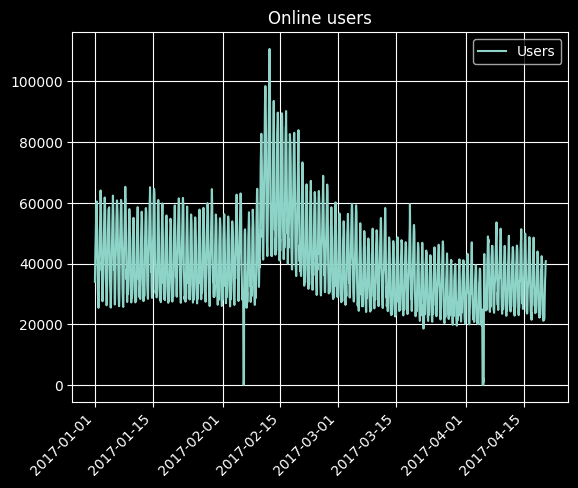

In [11]:
dataset = pd.read_csv('hour_online.csv', index_col=['Time'], parse_dates=['Time'])
plotly_df(dataset, title = "Online users")

In [12]:
def plotMovingAverage(series, n):
    """
    series - dataframe with timeseries
    n - rolling window size
    """
    rolling_mean = series.rolling(window=n).mean()
    rolling_std =  series.rolling(window=n).std()
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std

    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")

    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(dataset[n:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

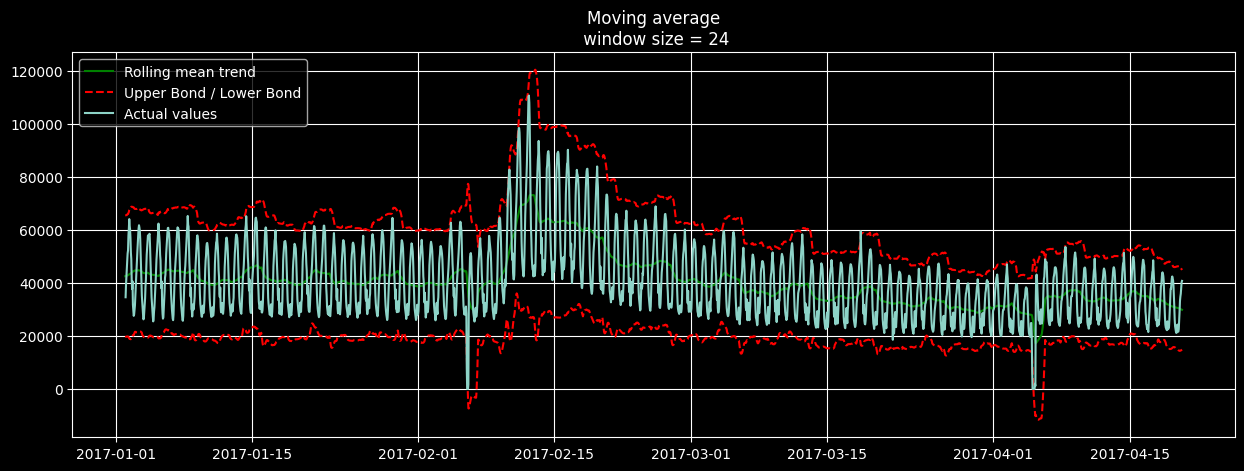

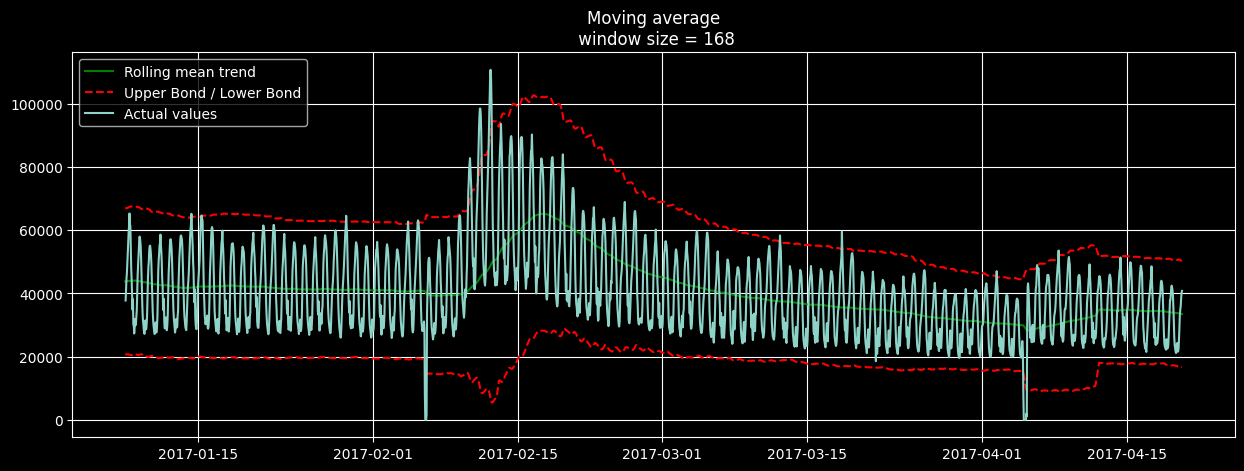

In [13]:
plotMovingAverage(dataset, 24)
plotMovingAverage(dataset, 24*7)

Из графиков видно, что есть прирост игроков каждую неделю по выходным. А так же заметна общая тенденция, рост в феврале и дальше спад.

Критерий Дики-Фуллера: p=0.190189


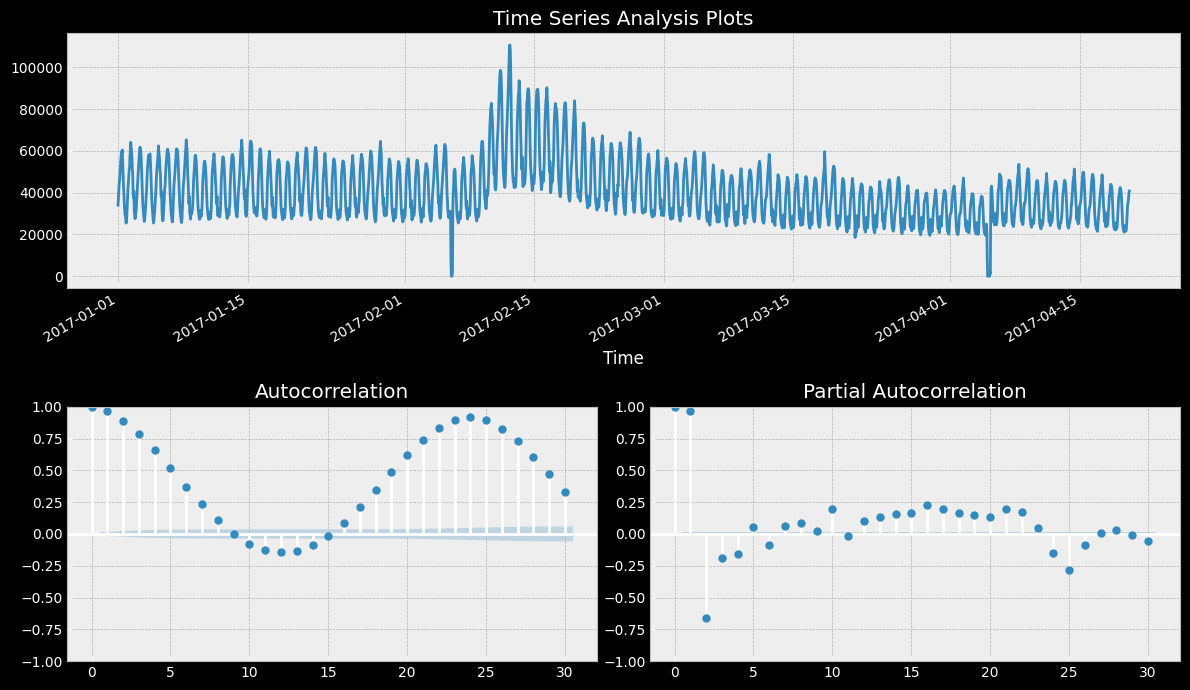

In [14]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        ts_ax.set_title('Time Series Analysis Plots')
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

        print("Критерий Дики-Фуллера: p=%f" % sm.tsa.stattools.adfuller(y)[1])

        plt.tight_layout()
    return

tsplot(dataset.Users, lags=30)

 Исходный ряд стационарным не является, критерий Дики-Фуллера не отверг нулевую гипотезу о наличии единичного корня.

In [8]:
data = dataset.copy()
data["Users_log"] = np.log1p(data["Users"])
tsplot(data.Users_log, lags=30)

NameError: name 'tsplot' is not defined

Критерий Дики-Фуллера отвергает нулевую гипотезу о нестационарности, но автокорреляционная функция всё ещё выглядит нехорошо из-за большого числа значимых лагов.

Критерий Дики-Фуллера: p=0.000000


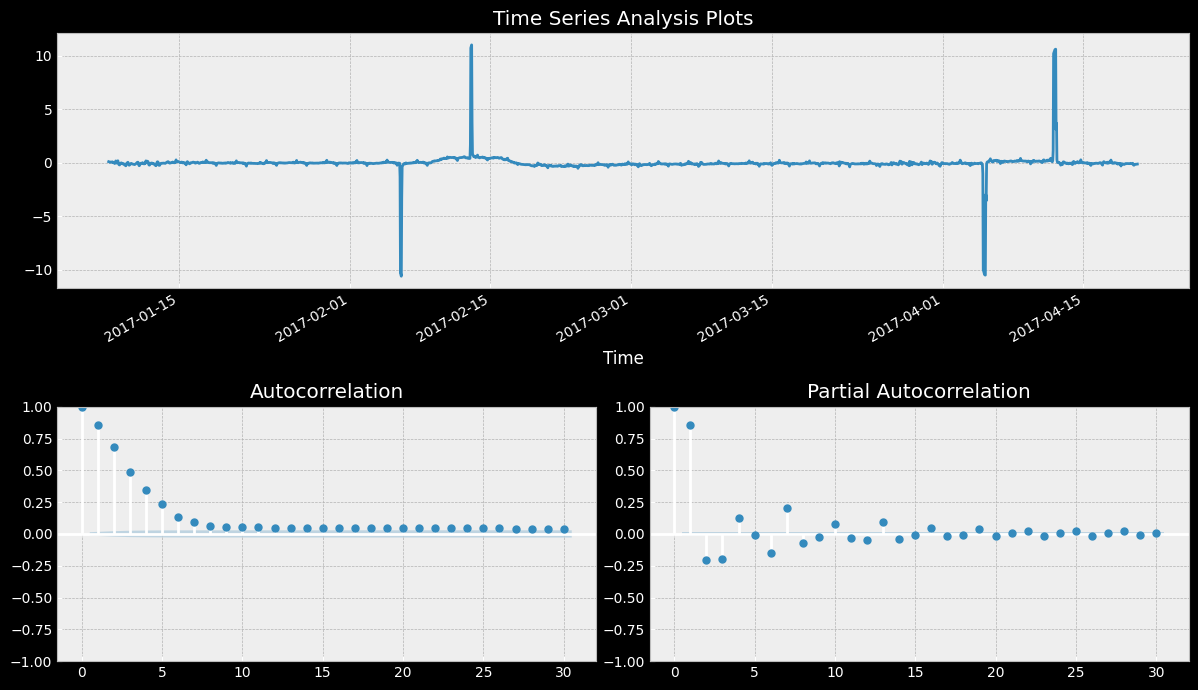

In [8]:
data['Users_log_season'] = data.Users_log - data.Users_log.shift(24*7)
tsplot(data.Users_log_season[24*7:], lags=30)

На графике частной автокорреляционной функции значим лишь один лаг, стоит взять еще первые разности, чтобы привести наконец ряд к стационарному виду.

Критерий Дики-Фуллера: p=0.000000


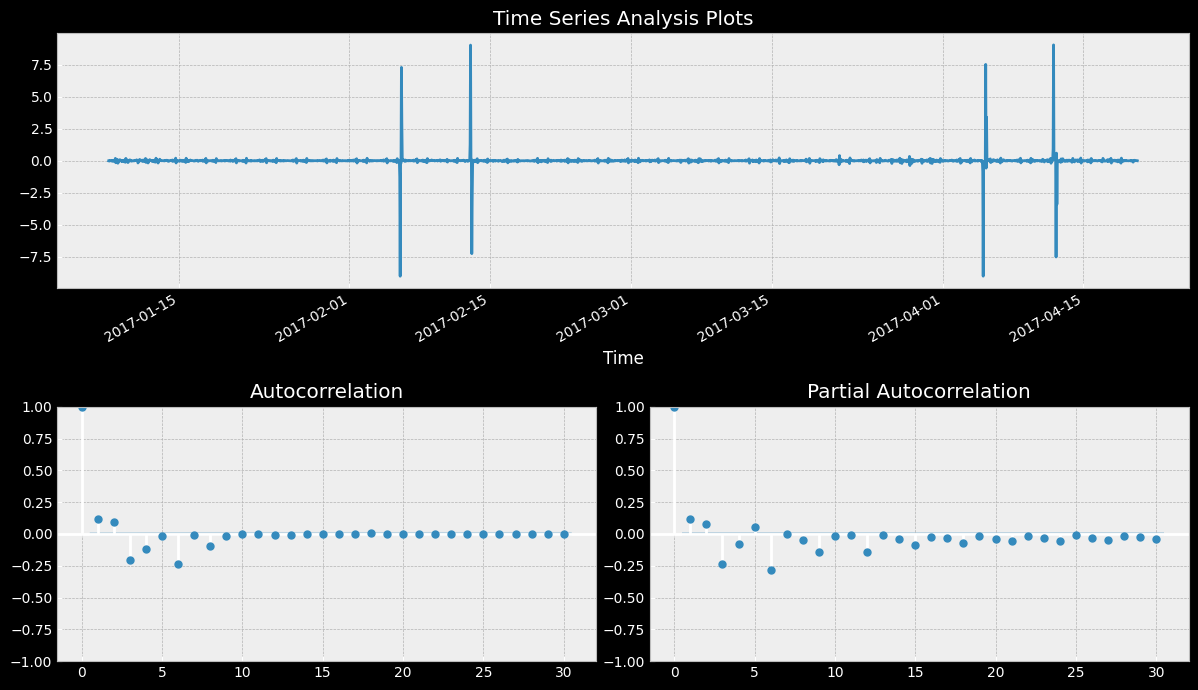

In [9]:
data['Users_log_season_diff'] = data.Users_log_season - data.Users_log_season.shift(1)
tsplot(data.Users_log_season_diff[24*7+1:], lags=30)

In [10]:
data_train = data.iloc[:-100].copy()
data_test = data.iloc[-100:].copy()

In [11]:
data_train["Users_log"] = np.log1p(data_train["Users"])
data_test["Users_log"] = np.log1p(data_test["Users"])

# SARIMA

In [22]:
ps = range(0, 5)
d=1
qs = range(0, 4)
Ps = range(0, 5)
D=1
Qs = range(0, 1)

parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

100

In [ ]:
best_model_SARIMA= sm.tsa.statespace.SARIMAX(data_train.Users_log, order=(4, d, 3),
                                        seasonal_order=(4, D, 1, 24)).fit(disp=-1)
print(best_model_SARIMA.summary())

In [ ]:
with open('sarima_model.pkl', 'wb') as f:
    pickle.dump(best_model_SARIMA, f)

params = {
    'order': (4, d, 3),
    'seasonal_order': (4, D, 1, 24),
    'params_estimated': best_model_SARIMA.params
}
with open('sarima_params.pkl', 'wb') as f:
    pickle.dump(params, f)

In [24]:
with open('sarima_model.pkl', 'rb') as f:
    best_model_SARIMA = pickle.load(f)

In [25]:
forecast_log_SARIMA = best_model_SARIMA.forecast(steps=len(data_test))
print("NaN in forecast_log:", forecast_log_SARIMA.isna().sum())
print("NaN in params:", best_model_SARIMA.params.isna().sum())

NaN in forecast_log: 0
NaN in params: 0


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
forecast_SARIMA = pd.Series(
    np.expm1(forecast_log_SARIMA.to_numpy()),   # без индексного выравнивания
    index=data_test.index
).clip(lower=0)

In [27]:
forecast_SARIMA

Time
2017-04-16 06:00:00    41359.497525
2017-04-16 07:00:00    45398.763210
2017-04-16 08:00:00    45469.463077
2017-04-16 09:00:00    48200.931287
2017-04-16 10:00:00    46943.696619
                           ...     
2017-04-20 05:00:00    29314.745683
2017-04-20 06:00:00    31263.855008
2017-04-20 07:00:00    38035.585742
2017-04-20 08:00:00    39517.335859
2017-04-20 09:00:00    43191.049747
Length: 100, dtype: float64

In [28]:
mae_test_sarima= mean_absolute_error(data_test['Users'], forecast_SARIMA)
print(f"Test MAE: {mae_test_sarima:.2f}")

Test MAE: 3047.70


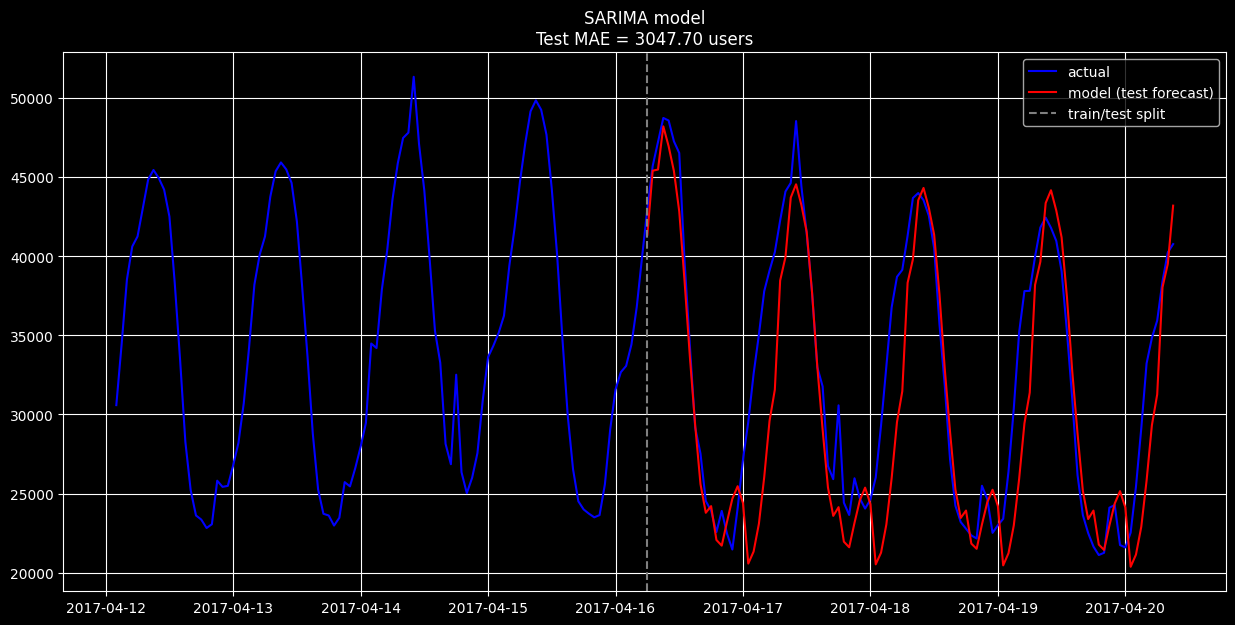

In [30]:
last_n = 200
actual_last = data['Users'].iloc[-last_n:]

# прогноз есть только на test, поэтому переиндексируем по фактическому окну
model_sarima_last = forecast_SARIMA.reindex(actual_last.index)

plt.figure(figsize=(15, 7))
plt.plot(actual_last, label='actual', color='blue')
plt.plot(model_sarima_last, label='model (test forecast)', color='red')

split_time = data_test.index[0]
if split_time >= actual_last.index.min():
    plt.axvline(split_time, color='gray', linestyle='--', label='train/test split')

plt.title(f"SARIMA model\nTest MAE = {mae_test_sarima:.2f} users")
plt.legend()
plt.grid(True)
plt.show()

**Test MAE: 3047.70**

# LSTM

In [31]:
# Функция univariate_data подготавливает данные для модели прогнозирования временных рядов.
def univariate_data(dataset, start_index, end_index, history_size, target_size):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i - history_size, i)
        data.append(np.reshape(dataset.iloc[list(indices)].to_numpy(), (history_size, 1)))
        labels.append(dataset.iloc[i + target_size])

    return np.array(data), np.array(labels)


In [32]:
tf.random.set_seed(13)

In [33]:
lstm_data = data['Users'].copy()
lstm_data_train = data['Users'].iloc[:-100].copy()
lstm_data_test  = data['Users'].iloc[-100:].copy()

In [34]:
lstm_data_train_mean = lstm_data_train.mean()
lstm_data_train_std = lstm_data_train.std()

In [35]:
train_size = len(lstm_data_train)
history_size = 24

In [36]:
lstm_data_normalize= (lstm_data-lstm_data_train_mean)/lstm_data_train_std

In [37]:
x_train_uni, y_train_uni = univariate_data(
    lstm_data_normalize, 0, train_size, history_size, 0
)

In [38]:
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])
simple_lstm_model.compile(optimizer='adam', loss='mae')

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
BATCH_SIZE = 256
BUFFER_SIZE = 1000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

# для валидации лучше без repeat
x_val_uni, y_val_uni = univariate_data(
    lstm_data_normalize, train_size - history_size, None, history_size, 0
)
val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni)).batch(BATCH_SIZE)

In [66]:
EPOCHS = 10
EVALUATION_INTERVAL = 5000

model_lstm = simple_lstm_model.fit(
    train_univariate,
    epochs=EPOCHS,
    steps_per_epoch=EVALUATION_INTERVAL,
    validation_data=val_univariate,
    verbose=1
)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - loss: 0.0794 - val_loss: 0.0660
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 0.0748 - val_loss: 0.0658
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 79s 16ms/step - loss: 0.0718 - val_loss: 0.0621
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - loss: 0.0697 - val_loss: 0.0615
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - loss: 0.0678 - val_loss: 0.0601
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 67s 13ms/step - loss: 0.0667 - val_loss: 0.0598
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 90s 18ms/step - loss: 0.0656 - val_loss: 0.0592
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 71s 14ms/step - loss: 0.0648 - val_loss: 0.0590
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0642 - val_loss: 0.0602
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0637 - val_loss: 0.0608


In [67]:
with open('model_lstm.pkl', 'wb') as f:
    pickle.dump(model_lstm.history, f)

In [68]:
train_pred_norm = simple_lstm_model.predict(x_train_uni, verbose=0).reshape(-1)
train_pred = train_pred_norm * lstm_data_train_std + lstm_data_train_mean

train_actual_aligned = data["Users"].iloc[history_size:train_size].to_numpy()

train_pred_tail = pd.Series(
    train_pred[-100:],
    index=data.index[train_size-100:train_size]
)

In [69]:
series_norm = lstm_data_normalize.to_numpy()

window = series_norm[train_size-history_size:train_size].reshape(1, history_size, 1)
forecast_norm = []

for _ in range(100):
    next_pred = simple_lstm_model.predict(window, verbose=0)[0, 0]
    forecast_norm.append(next_pred)
    window = np.concatenate([window[:, 1:, :], np.array(next_pred).reshape(1, 1, 1)], axis=1)

forecast_100 = np.array(forecast_norm) * lstm_data_train_std + lstm_data_train_mean
forecast_100 = pd.Series(forecast_100, index=data.index[train_size:train_size+100])


In [70]:
true_100 = lstm_data_test.iloc[:100].to_numpy()
mae_test = mean_absolute_error(true_100, forecast_100.to_numpy())
print(f"Test MAE (100 steps): {mae_test:.2f}")


Test MAE (100 steps): 1943.23


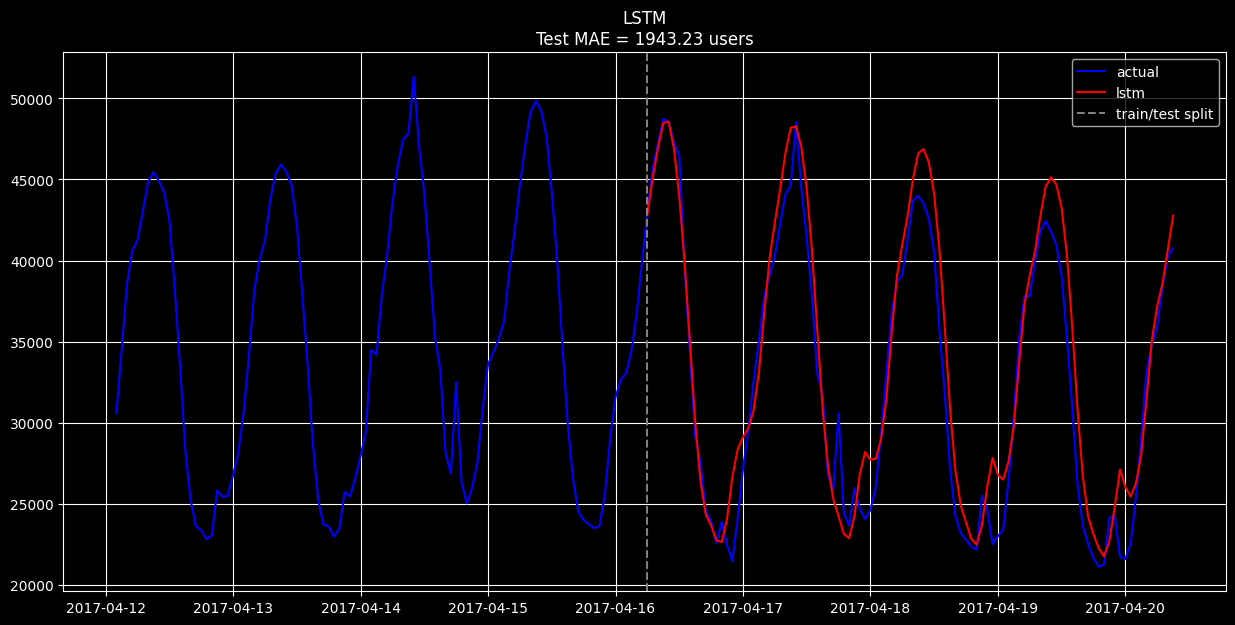

In [71]:
actual_last_200 = data["Users"].iloc[-200:]
pred_last_200 = pd.concat([train_pred_tail, forecast_100])

plt.figure(figsize=(15, 7))
plt.plot(actual_last_200.index, actual_last_200.values, label="actual", color="blue")
plt.plot(pred_last_200[100:].index, pred_last_200[100:].values, label="lstm", color="red")
plt.axvline(data.index[train_size], color="gray", linestyle="--", label="train/test split")
plt.title(f"LSTM\nTest MAE = {mae_test:.2f} users")
plt.legend()
plt.grid(True)
plt.show()

**Test MAE: 1943.23**

# Данные с пропусками

Были созданы наборы данных с пропусками данных (5%, 10%, 20%). Данные пропускаются блоками, что больше соответствует реальным ситуациям.

In [3]:
def add_block_missing_by_percent(data, missing_percent=0.5, block_size=24):
    data_missing = data.copy()
    n = len(data)

    total_missing = int(n * missing_percent)
    current_missing = 0

    used = np.zeros(n, dtype=bool)

    while current_missing < total_missing:
        start = np.random.randint(0, n - block_size)

        # проверяем пересечения
        if not used[start:start+block_size].any():
            end = start + block_size

            used[start:end] = True
            data_missing[start:end] = np.nan

            current_missing += block_size

    return data_missing

Так как в чистом виде нельзя передавать в модели данные с пропуском их необходимо заполнить. Для заполнения пропусков использовалась замена пропусков на среднее значение.

In [78]:
def fillna_mean(data):
     return data.fillna(data.mean())

In [15]:
data_train_missing_5 = pd.DataFrame(add_block_missing_by_percent((data['Users'].iloc[:-100]), missing_percent=0.05))
data_train_missing_10 = pd.DataFrame(add_block_missing_by_percent((data['Users'].iloc[:-100]), missing_percent=0.1))
data_train_missing_20 = pd.DataFrame(add_block_missing_by_percent((data['Users'].iloc[:-100]), missing_percent=0.2))
data_test  = pd.DataFrame(data['Users'].iloc[-100:].copy())

<Axes: xlabel='Time'>

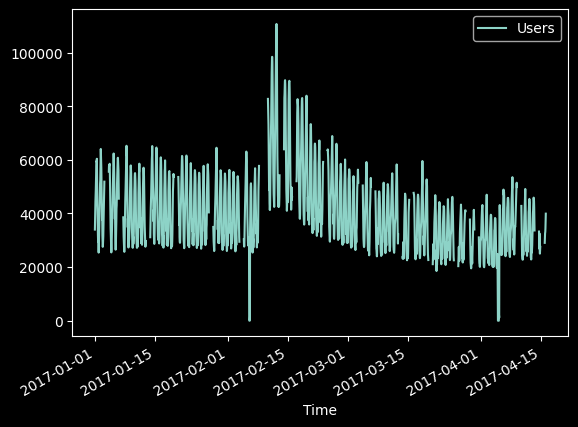

In [17]:
data_train_missing_20.plot()

In [81]:
def sarima_pipline(data_missing, missing_percent, model=None):
    data_missing = fillna_mean(data_missing)
    data_missing["Users_log"] = np.log1p(data_missing["Users"])

    if model:
        with open(model, 'rb') as f:
            model_SARIMA = pickle.load(f)
    else:
        model_SARIMA= sm.tsa.statespace.SARIMAX(data_missing.Users_log, order=(4, d, 3),
                                            seasonal_order=(4, D, 1, 24)).fit(disp=-1)
        with open(f'sarima_model_{missing_percent}.pkl', 'wb') as f:
            pickle.dump(model_SARIMA, f)
        print("SARIMA model saved")

    forecast_log_SARIMA = model_SARIMA.forecast(steps=len(data_test))

    forecast_SARIMA = pd.Series(
    np.expm1(forecast_log_SARIMA.to_numpy()),   # без индексного выравнивания
    index=data_test.index).clip(lower=0)

    mae_test_sarima = mean_absolute_error(data_test['Users'], forecast_SARIMA)
    print(f"Test with {missing_percent*100}% missing MAE: {mae_test_sarima:.2f}")

    last_n = 200
    actual_last = data['Users'].iloc[-last_n:]

    # прогноз есть только на test, поэтому переиндексируем по фактическому окну
    model_sarima_last = forecast_SARIMA.reindex(actual_last.index)

    plt.figure(figsize=(15, 7))
    plt.plot(actual_last, label='actual', color='blue')
    plt.plot(model_sarima_last, label='model (test forecast)', color='red')

    split_time = data_test.index[0]
    if split_time >= actual_last.index.min():
        plt.axvline(split_time, color='gray', linestyle='--', label='train/test split')

    plt.title(f"SARIMA model\nTest with {missing_percent*100}% MAE = {mae_test_sarima:.2f} users")
    plt.legend()
    plt.grid(True)
    plt.show()

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA model saved


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Test with 5.0% missing MAE: 3022.86


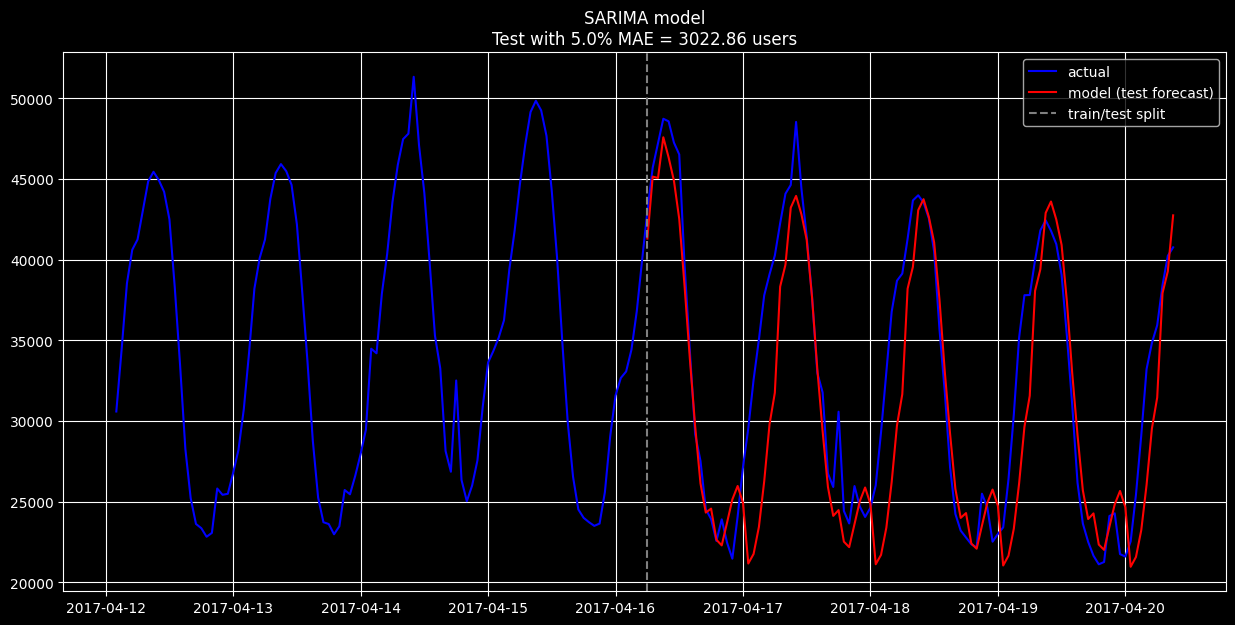

In [91]:
sarima_pipline(data_train_missing_5, missing_percent=0.05)

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA model saved


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Test with 10.0% missing MAE: 3047.50


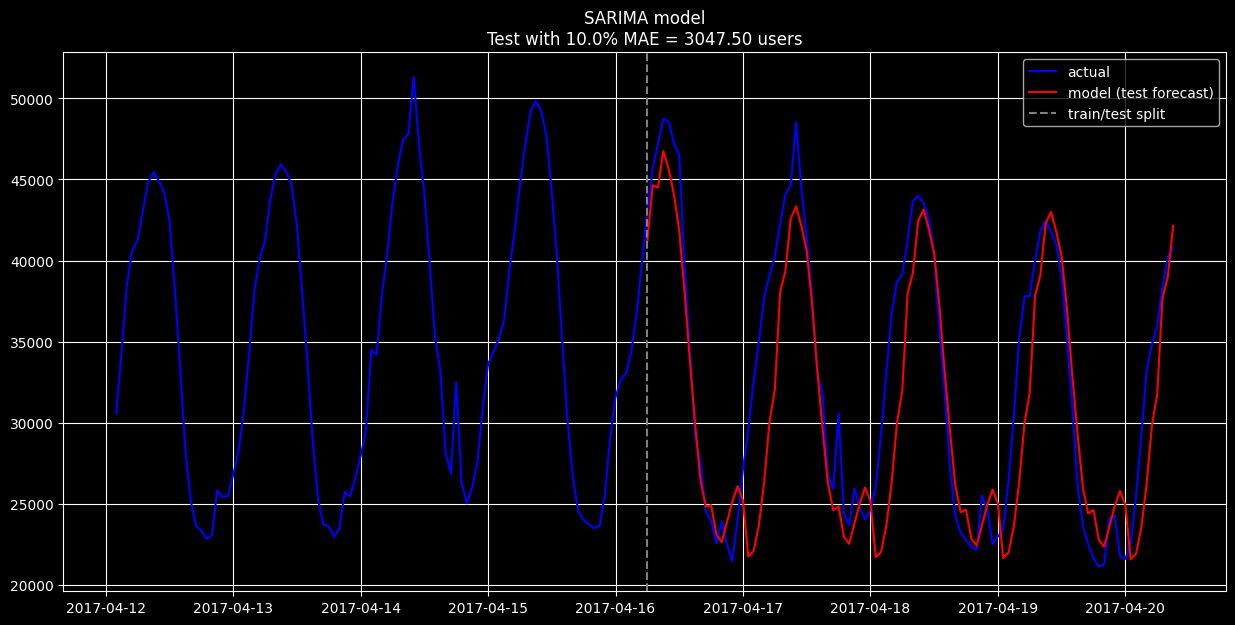

In [92]:
sarima_pipline(data_train_missing_10, missing_percent=0.1)

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA model saved
Test with 20.0% missing MAE: 3232.37


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


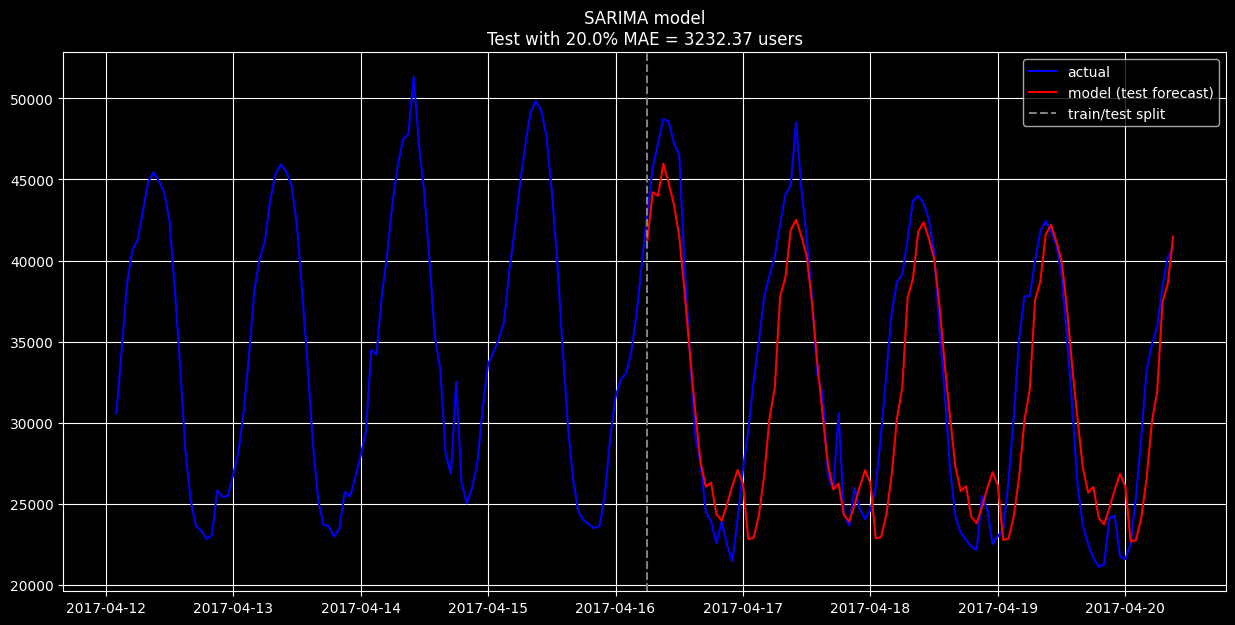

In [93]:
sarima_pipline(data_train_missing_20, missing_percent=0.2)

In [85]:
def lstm_pipline(data_missing, missing_percent, model=None):
    data_missing = fillna_mean(data_missing)

    lstm_data_train = data_missing["Users"].copy()

    lstm_data_train_mean = lstm_data_train.mean()
    lstm_data_train_std = lstm_data_train.std()

    train_size = len(lstm_data_train)
    history_size = 24

    lstm_data_normalize= (lstm_data-lstm_data_train_mean)/lstm_data_train_std

    x_train_uni, y_train_uni = univariate_data(
    lstm_data_normalize, 0, train_size, history_size, 0)

    simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
    ])
    simple_lstm_model.compile(optimizer='adam', loss='mae')

    BATCH_SIZE = 256
    BUFFER_SIZE = 1000

    train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
    train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

    # для валидации лучше без repeat
    x_val_uni, y_val_uni = univariate_data(
        lstm_data_normalize, train_size - history_size, None, history_size, 0
    )
    val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni)).batch(BATCH_SIZE)

    EPOCHS = 10
    EVALUATION_INTERVAL = 5000

    model_lstm = simple_lstm_model.fit(
        train_univariate,
        epochs=EPOCHS,
        steps_per_epoch=EVALUATION_INTERVAL,
        validation_data=val_univariate,
        verbose=1)


    train_pred_norm = simple_lstm_model.predict(x_train_uni, verbose=0).reshape(-1)
    train_pred = train_pred_norm * lstm_data_train_std + lstm_data_train_mean

    train_actual_aligned = data["Users"].iloc[history_size:train_size].to_numpy()

    train_pred_tail = pd.Series(
        train_pred[-100:],
        index=data.index[train_size-100:train_size])

    series_norm = lstm_data_normalize.to_numpy()

    window = series_norm[train_size-history_size:train_size].reshape(1, history_size, 1)
    forecast_norm = []

    for _ in range(100):
        next_pred = simple_lstm_model.predict(window, verbose=0)[0, 0]
        forecast_norm.append(next_pred)
        window = np.concatenate([window[:, 1:, :], np.array(next_pred).reshape(1, 1, 1)], axis=1)

    forecast_100 = np.array(forecast_norm) * lstm_data_train_std + lstm_data_train_mean
    forecast_100 = pd.Series(forecast_100, index=data.index[train_size:train_size+100])

    true_100 = lstm_data_test.iloc[:100].to_numpy()
    mae_test = mean_absolute_error(true_100, forecast_100.to_numpy())
    print(f"Test MAE (100 steps): {mae_test:.2f}")

    actual_last_200 = data["Users"].iloc[-200:]
    pred_last_200 = pd.concat([train_pred_tail, forecast_100])

    plt.figure(figsize=(15, 7))
    plt.plot(actual_last_200.index, actual_last_200.values, label="actual", color="blue")
    plt.plot(pred_last_200[100:].index, pred_last_200[100:].values, label="lstm", color="red")
    plt.axvline(data.index[train_size], color="gray", linestyle="--", label="train/test split")
    plt.title(f"LSTM\nTest MAE = {mae_test:.2f} users")
    plt.legend()
    plt.grid(True)
    plt.show()

D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 0.1184 - val_loss: 0.0696
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 0.0858 - val_loss: 0.0682
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 56s 11ms/step - loss: 0.0818 - val_loss: 0.0687
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 0.0799 - val_loss: 0.0657
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - loss: 0.0787 - val_loss: 0.0670
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.0778 - val_loss: 0.0646
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.0769 - val_loss: 0.0677
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 0.0760 - val_loss: 0.0693
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - loss: 0.0753 - val_loss: 0.0669
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 72s 14ms/step - loss: 0.0746 - val_loss: 0.0676
Test MAE (100 steps): 4139.69


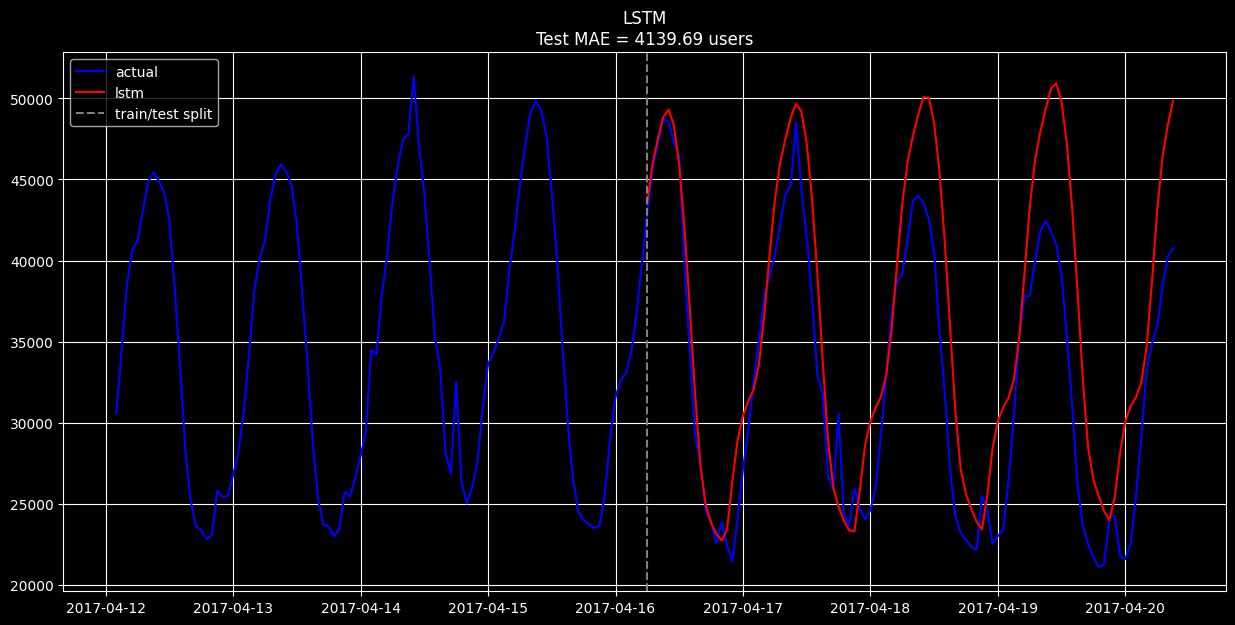

In [86]:
lstm_pipline(data_train_missing_5, missing_percent=0.05)

Epoch 1/10


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - loss: 0.1200 - val_loss: 0.0718
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 64s 13ms/step - loss: 0.0868 - val_loss: 0.0696
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.0819 - val_loss: 0.0658
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 67s 13ms/step - loss: 0.0786 - val_loss: 0.0647
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 60s 12ms/step - loss: 0.0761 - val_loss: 0.0611
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.0739 - val_loss: 0.0625
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 63s 13ms/step - loss: 0.0725 - val_loss: 0.0623
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - loss: 0.0714 - val_loss: 0.0626
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 68s 14ms/step - loss: 0.0703 - val_loss: 0.0614
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.0693 - val_loss: 0.0606
Test MAE (100 steps): 3553.88


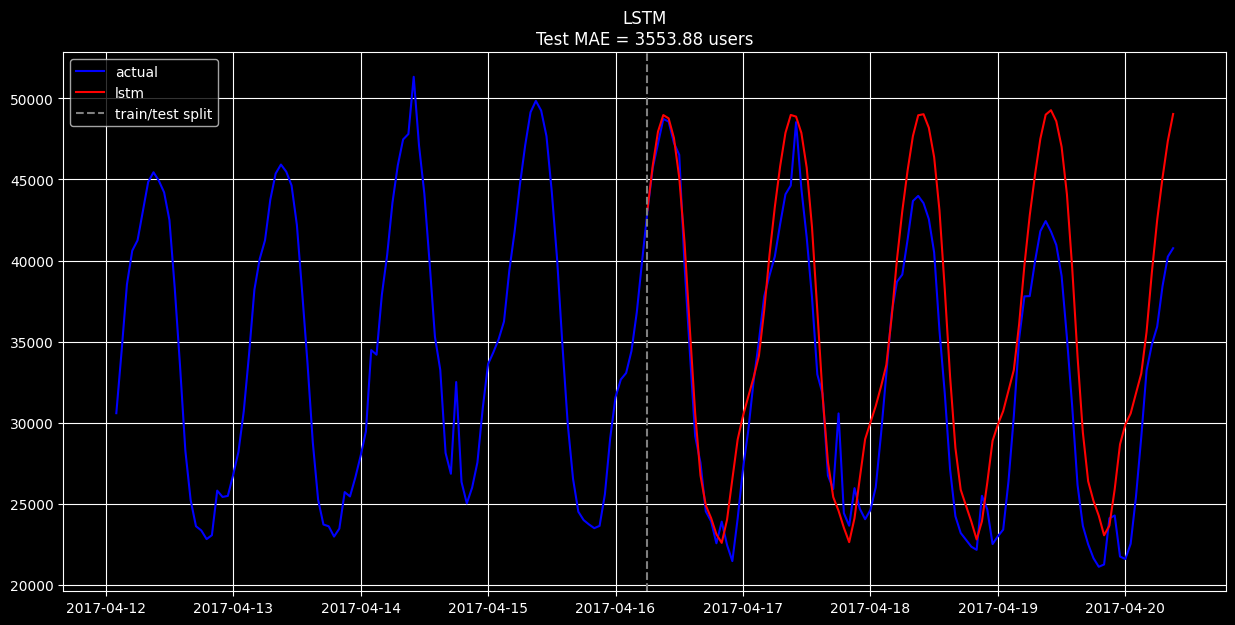

In [87]:
lstm_pipline(data_train_missing_10, missing_percent=0.1)

Epoch 1/10


D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
D:\SUAI\Научная статья\ARIMA_vs_LSTM\venv\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 59s 11ms/step - loss: 0.1537 - val_loss: 0.0829
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 59s 12ms/step - loss: 0.0965 - val_loss: 0.0779
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 56s 11ms/step - loss: 0.0911 - val_loss: 0.0753
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0882 - val_loss: 0.0721
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0853 - val_loss: 0.0730
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0825 - val_loss: 0.0712
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0802 - val_loss: 0.0718
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0780 - val_loss: 0.0707
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 0.0763 - val_loss: 0.0719
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - loss: 0.0750 - val_loss: 0.0730
Test MAE (100 steps): 2626.19


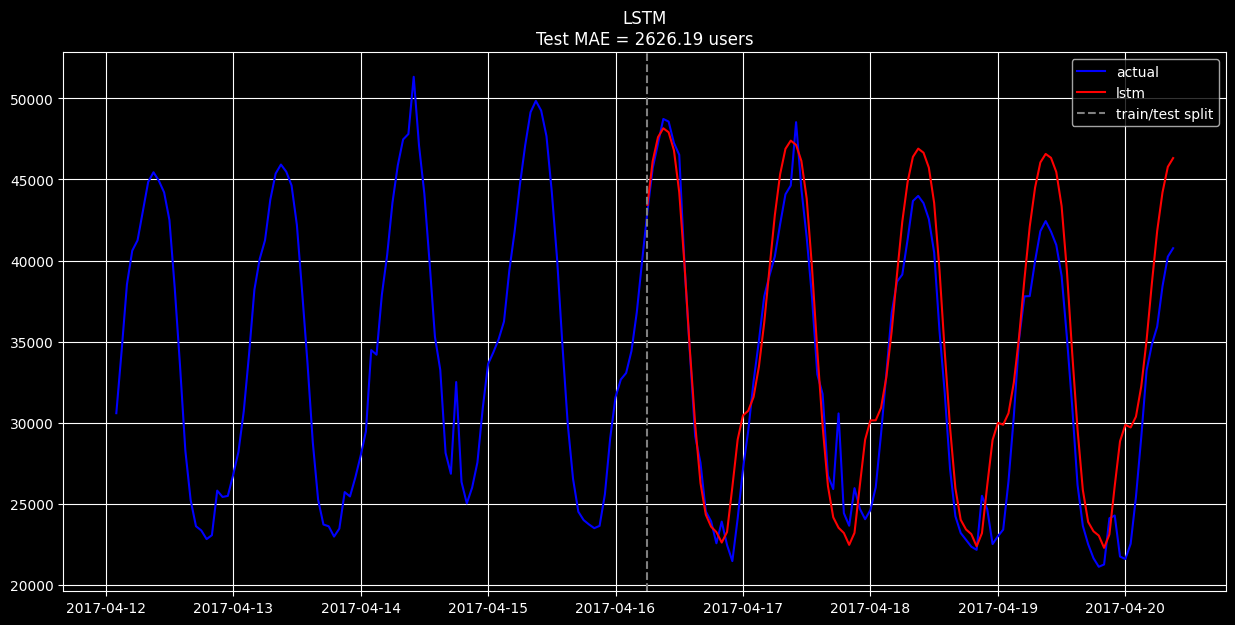

In [88]:
lstm_pipline(data_train_missing_20, missing_percent=0.2)

In [89]:
print('SARIMA:')
print(((3397.02-3047.70)+(3268.81-3047.70)+(5023.71-3047.70))/3)

SARIMA:
848.8133333333335


In [90]:
print('LSTM:')
print(((1461.43-2161.43)+(3472.61-2161.43)+(2959.79-2161.43))/3)

LSTM:
469.84666666666686
